# Style Error Analysis for Multi-Label Relabeling

## 1. Objective

The objective of this notebook is to inspect the current selected style classifier and identify which training or evaluation images may need multi-label relabeling.

The current style classifier is trained as a single-label classifier. This means every clothing image is forced into one aesthetic class:

- formal
- gothic
- sporty
- streetwear

However, teacher feedback pointed out that real clothing items can belong to more than one aesthetic at the same time. For example, a t-shirt can be both sporty and streetwear.

The goal of this experiment is not to immediately retrain the model. Instead, the goal is to first inspect model mistakes, high-loss images, and low-confidence boundary cases. Based on this analysis, only the most relevant images will be manually reviewed for possible multi-label relabeling.

The main research question is:

**Can model errors and uncertainty patterns show which fashion images should be reviewed for possible multi-label relabeling?**

## 2. Project Context

The current selected prototype uses:

- MobileNetV3 Large for style classification
- improved ResNet34 for clothing type classification
- CLIP embeddings for recommendation ranking

Previous experiments showed that MobileNetV3 Large improved style prediction compared with the previous ResNet34 style classifier. However, style classification is still not fully reliable, especially for visually overlapping styles such as sporty, streetwear, and gothic.

The application already supports multi-style recommendations at the software level by using the full style probability distribution. When the model is uncertain or when another style has a similar probability, the app can show multiple aesthetic directions.

However, the model itself is still trained as a single-label classifier. This experiment investigates whether a future multi-label training approach would be justified, and where relabeling should be focused.

## 3. Experiment Design

This experiment uses the current selected MobileNetV3 Large style classifier.

The model will be evaluated image by image on the available style datasets. For every image, the notebook records:

- true style label from the folder structure
- predicted style
- prediction confidence
- second-best predicted style
- confidence gap between top-1 and top-2
- per-image cross-entropy loss
- whether the prediction is correct
- whether the image belongs to a known boundary pair

The analysis focuses on three types of useful candidates:

1. **Wrong predictions**  
   These show where the current label and model prediction disagree.

2. **High-loss images**  
   These show where the model strongly struggles with the current label.

3. **Low-margin predictions**  
   These show images where the model sees two styles as close possibilities.

The goal is to create a candidate list for manual review. The model will not automatically relabel images. It will only help identify which images are worth inspecting.

## 4. Imports and setup

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import models, transforms

from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
    print("GPU:", torch.cuda.get_device_name(0))
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

print("Torch version:", torch.__version__)

Using device: CUDA
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Torch version: 2.11.0+cu130


## 5. Paths

In [2]:
# Paths
style_model_path = Path("../models/style_mobilenet_v3_large_architecture_comparison.pth")

split_style_root = Path("../dataset/split_style")
style_extra_root = Path("../dataset/style_extra")
real_world_root = Path("../dataset/real_world_test")

results_dir = Path("../results/style_multilabel_error_analysis")
results_dir.mkdir(parents=True, exist_ok=True)

manual_review_dir = results_dir / "manual_review"
manual_review_dir.mkdir(parents=True, exist_ok=True)

print("Style model exists:", style_model_path.exists())
print("split_style exists:", split_style_root.exists())
print("style_extra exists:", style_extra_root.exists())
print("real_world_test exists:", real_world_root.exists())
print("Results folder:", results_dir)

Style model exists: True
split_style exists: True
style_extra exists: True
real_world_test exists: True
Results folder: ..\results\style_multilabel_error_analysis


## 6. Load current selected style model

In [3]:
def load_mobilenet_v3_style_classifier(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    if isinstance(checkpoint, dict) and "class_names" in checkpoint:
        class_names = checkpoint["class_names"]
    else:
        class_names = ["formal", "gothic", "sporty", "streetwear"]

    model = models.mobilenet_v3_large(weights=None)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, len(class_names))

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()

    return model, class_names


style_model, class_names = load_mobilenet_v3_style_classifier(style_model_path)

class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

print("Loaded style model.")
print("Class names:", class_names)
print("Class mapping:", class_to_idx)

Loaded style model.
Class names: ['formal', 'gothic', 'sporty', 'streetwear']
Class mapping: {'formal': 0, 'gothic': 1, 'sporty': 2, 'streetwear': 3}


## 7. Image transform

In [4]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 8. Collect image samples

In [5]:
valid_extensions = (".jpg", ".jpeg", ".png", ".webp")


def collect_split_style_samples(split_style_root, split_name):
    """
    Collects images from:
    split_style/train/style/image
    split_style/val/style/image
    split_style/test/style/image
    """

    split_dir = split_style_root / split_name
    samples = []

    if not split_dir.exists():
        print(f"Missing split folder: {split_dir}")
        return samples

    for style in sorted(os.listdir(split_dir)):
        style_path = split_dir / style

        if not style_path.is_dir():
            continue

        if style not in class_to_idx:
            print(f"Skipping unknown style folder: {style}")
            continue

        for filename in sorted(os.listdir(style_path)):
            image_path = style_path / filename

            if image_path.is_file() and filename.lower().endswith(valid_extensions):
                samples.append({
                    "source": f"split_style_{split_name}",
                    "split": split_name,
                    "image_path": str(image_path),
                    "filename": filename,
                    "true_style": style,
                    "true_label": class_to_idx[style]
                })

    return samples


def collect_style_extra_samples(style_extra_root):
    """
    Collects images recursively from:
    style_extra/style/.../image

    This supports both:
    style_extra/streetwear/image.png
    and:
    style_extra/streetwear/tshirt/image.png
    """

    samples = []

    if not style_extra_root.exists():
        print(f"Missing style_extra folder: {style_extra_root}")
        return samples

    for style in sorted(os.listdir(style_extra_root)):
        style_path = style_extra_root / style

        if not style_path.is_dir():
            continue

        if style not in class_to_idx:
            print(f"Skipping unknown style folder: {style}")
            continue

        for current_root, _, files in os.walk(style_path):
            for filename in sorted(files):
                if not filename.lower().endswith(valid_extensions):
                    continue

                image_path = Path(current_root) / filename

                samples.append({
                    "source": "style_extra",
                    "split": "style_extra",
                    "image_path": str(image_path),
                    "filename": filename,
                    "true_style": style,
                    "true_label": class_to_idx[style]
                })

    return samples


def collect_real_world_samples(real_world_root):
    """
    Collects images from:
    real_world_test/style/type/image

    This dataset is evaluation only. It will be analysed, but it must not be used for retraining.
    """

    samples = []

    if not real_world_root.exists():
        print(f"Missing real_world_test folder: {real_world_root}")
        return samples

    for style in sorted(os.listdir(real_world_root)):
        style_path = real_world_root / style

        if not style_path.is_dir():
            continue

        if style not in class_to_idx:
            print(f"Skipping unknown style folder: {style}")
            continue

        for item_type in sorted(os.listdir(style_path)):
            type_path = style_path / item_type

            if not type_path.is_dir():
                continue

            for filename in sorted(os.listdir(type_path)):
                image_path = type_path / filename

                if image_path.is_file() and filename.lower().endswith(valid_extensions):
                    samples.append({
                        "source": "real_world_test",
                        "split": "real_world_test",
                        "image_path": str(image_path),
                        "filename": filename,
                        "true_style": style,
                        "true_label": class_to_idx[style],
                        "type": item_type
                    })

    return samples


all_samples = []

for split_name in ["train", "val", "test"]:
    all_samples.extend(
        collect_split_style_samples(split_style_root, split_name)
    )

all_samples.extend(
    collect_style_extra_samples(style_extra_root)
)

all_samples.extend(
    collect_real_world_samples(real_world_root)
)

samples_df = pd.DataFrame(all_samples)

print("Total samples collected:", len(samples_df))
print(samples_df["source"].value_counts())

samples_df.head()

Total samples collected: 980
source
split_style_train    560
split_style_val      120
split_style_test     120
style_extra          100
real_world_test       80
Name: count, dtype: int64


,source,split,image_path,filename,true_style,true_label,type
0,split_style_train,train,..\dataset\split_style\train\formal\jacket_for...,jacket_formal_jacket_001.png,formal,0,NaN
1,split_style_train,train,..\dataset\split_style\train\formal\jacket_for...,jacket_formal_jacket_003.png,formal,0,NaN
2,split_style_train,train,..\dataset\split_style\train\formal\jacket_for...,jacket_formal_jacket_004.png,formal,0,NaN
3,split_style_train,train,..\dataset\split_style\train\formal\jacket_for...,jacket_formal_jacket_005.png,formal,0,NaN
4,split_style_train,train,..\dataset\split_style\train\formal\jacket_for...,jacket_formal_jacket_006.png,formal,0,NaN


## 9. Run per-image error analysis

In [6]:
def predict_single_image(image_path, true_label):
    image = Image.open(image_path).convert("RGB")
    input_tensor = eval_transform(image).unsqueeze(0).to(device)

    true_label_tensor = torch.tensor([true_label], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = style_model(input_tensor)
        probs = torch.softmax(logits, dim=1)

        loss = F.cross_entropy(logits, true_label_tensor, reduction="none").item()

        sorted_probs, sorted_indices = torch.sort(probs[0], descending=True)

        top_idx = sorted_indices[0].item()
        second_idx = sorted_indices[1].item()

        top_style = idx_to_class[top_idx]
        second_style = idx_to_class[second_idx]

        top_confidence = sorted_probs[0].item()
        second_confidence = sorted_probs[1].item()

        probability_values = probs[0].cpu().numpy()

    result = {
        "predicted_style": top_style,
        "predicted_label": top_idx,
        "top_confidence": top_confidence,
        "second_style": second_style,
        "second_confidence": second_confidence,
        "confidence_margin": top_confidence - second_confidence,
        "loss": loss,
        "correct": top_idx == true_label
    }

    for class_name, probability in zip(class_names, probability_values):
        result[f"prob_{class_name}"] = probability

    return result


analysis_rows = []

for idx, row in samples_df.iterrows():
    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1}/{len(samples_df)} images")

    prediction_info = predict_single_image(
        image_path=row["image_path"],
        true_label=row["true_label"]
    )

    analysis_rows.append({
        **row.to_dict(),
        **prediction_info
    })

analysis_df = pd.DataFrame(analysis_rows)

analysis_df.head()

Processed 100/980 images
Processed 200/980 images
Processed 300/980 images
Processed 400/980 images
Processed 500/980 images
Processed 600/980 images
Processed 700/980 images
Processed 800/980 images
Processed 900/980 images


,source,split,image_path,filename,true_style,true_label,type,predicted_style,predicted_label,top_confidence,second_style,second_confidence,confidence_margin,loss,correct,prob_formal,prob_gothic,prob_sporty,prob_streetwear
0,split_style_train,train,..\dataset\split_style\train\formal\jacket_for...,jacket_formal_jacket_001.png,formal,0,NaN,formal,0,0.659018,sporty,0.214922,0.444096,0.417004,True,0.659018,0.027543,0.214922,0.098516
1,split_style_train,train,..\dataset\split_style\train\formal\jacket_for...,jacket_formal_jacket_003.png,formal,0,NaN,formal,0,0.865472,streetwear,0.080630,0.784842,0.144480,True,0.865472,0.005783,0.048115,0.080630
2,split_style_train,train,..\dataset\split_style\train\formal\jacket_for...,jacket_formal_jacket_004.png,formal,0,NaN,formal,0,0.918088,sporty,0.039724,0.878363,0.085463,True,0.918088,0.015201,0.039724,0.026987
3,split_style_train,train,..\dataset\split_style\train\formal\jacket_for...,jacket_formal_jacket_005.png,formal,0,NaN,formal,0,0.948624,streetwear,0.025414,0.923210,0.052743,True,0.948624,0.007687,0.018275,0.025414
4,split_style_train,train,..\dataset\split_style\train\formal\jacket_for...,jacket_formal_jacket_006.png,formal,0,NaN,formal,0,0.908826,sporty,0.061735,0.847090,0.095602,True,0.908826,0.012258,0.061735,0.017181


## 10. Add candidate flags

In [7]:
# Thresholds for candidate selection
high_loss_quantile = 0.90
low_margin_threshold = 0.20
low_confidence_threshold = 0.60

high_loss_threshold = analysis_df["loss"].quantile(high_loss_quantile)

boundary_pairs = {
    frozenset(["sporty", "streetwear"]),
    frozenset(["gothic", "streetwear"]),
    frozenset(["gothic", "sporty"]),
    frozenset(["formal", "streetwear"])
}


def is_boundary_pair(row):
    pair = frozenset([row["predicted_style"], row["second_style"]])
    return pair in boundary_pairs


analysis_df["wrong_prediction"] = ~analysis_df["correct"]
analysis_df["high_loss"] = analysis_df["loss"] >= high_loss_threshold
analysis_df["low_margin"] = analysis_df["confidence_margin"] <= low_margin_threshold
analysis_df["low_confidence"] = analysis_df["top_confidence"] < low_confidence_threshold
analysis_df["boundary_pair"] = analysis_df.apply(is_boundary_pair, axis=1)

analysis_df["candidate_for_manual_review"] = (
    analysis_df["boundary_pair"] &
    (
        analysis_df["wrong_prediction"] |
        analysis_df["high_loss"] |
        analysis_df["low_margin"] |
        analysis_df["low_confidence"]
    )
)

print("High loss threshold:", high_loss_threshold)
print("Manual review candidates:", analysis_df["candidate_for_manual_review"].sum())

analysis_df[
    [
        "source",
        "true_style",
        "predicted_style",
        "second_style",
        "top_confidence",
        "second_confidence",
        "confidence_margin",
        "loss",
        "correct",
        "boundary_pair",
        "candidate_for_manual_review"
    ]
].head()

High loss threshold: 1.0307825207710268
Manual review candidates: 209


,source,true_style,predicted_style,second_style,top_confidence,second_confidence,confidence_margin,loss,correct,boundary_pair,candidate_for_manual_review
0,split_style_train,formal,formal,sporty,0.659018,0.214922,0.444096,0.417004,True,False,False
1,split_style_train,formal,formal,streetwear,0.865472,0.080630,0.784842,0.144480,True,True,False
2,split_style_train,formal,formal,sporty,0.918088,0.039724,0.878363,0.085463,True,False,False
3,split_style_train,formal,formal,streetwear,0.948624,0.025414,0.923210,0.052743,True,True,False
4,split_style_train,formal,formal,sporty,0.908826,0.061735,0.847090,0.095602,True,False,False


## 11. Save result tables

In [8]:
all_results_path = results_dir / "style_error_analysis_all_images.csv"
candidate_results_path = results_dir / "style_multilabel_manual_review_candidates.csv"

analysis_df.to_csv(all_results_path, index=False)

candidate_df = analysis_df[
    analysis_df["candidate_for_manual_review"]
].copy()

candidate_df = candidate_df.sort_values(
    by=["source", "loss", "confidence_margin"],
    ascending=[True, False, True]
)

candidate_df.to_csv(candidate_results_path, index=False)

print("Saved all image analysis to:", all_results_path)
print("Saved manual review candidates to:", candidate_results_path)
print("Candidate count:", len(candidate_df))

Saved all image analysis to: ..\results\style_multilabel_error_analysis\style_error_analysis_all_images.csv
Saved manual review candidates to: ..\results\style_multilabel_error_analysis\style_multilabel_manual_review_candidates.csv
Candidate count: 209


## 12. Summary tables

In [9]:
summary_by_source = analysis_df.groupby("source").agg(
    num_images=("filename", "count"),
    accuracy=("correct", "mean"),
    avg_loss=("loss", "mean"),
    wrong_predictions=("wrong_prediction", "sum"),
    high_loss_count=("high_loss", "sum"),
    low_margin_count=("low_margin", "sum"),
    low_confidence_count=("low_confidence", "sum"),
    boundary_pair_count=("boundary_pair", "sum"),
    candidate_count=("candidate_for_manual_review", "sum")
).reset_index()

summary_by_true_style = analysis_df.groupby(["source", "true_style"]).agg(
    num_images=("filename", "count"),
    accuracy=("correct", "mean"),
    avg_loss=("loss", "mean"),
    wrong_predictions=("wrong_prediction", "sum"),
    low_margin_count=("low_margin", "sum"),
    candidate_count=("candidate_for_manual_review", "sum")
).reset_index()

confusion_table = pd.crosstab(
    analysis_df["true_style"],
    analysis_df["predicted_style"]
)

boundary_confusions = analysis_df[
    analysis_df["wrong_prediction"]
].groupby(
    ["true_style", "predicted_style"]
).size().reset_index(name="count").sort_values(
    by="count",
    ascending=False
)

display(summary_by_source)
display(summary_by_true_style)
display(confusion_table)
display(boundary_confusions)

summary_by_source.to_csv(results_dir / "summary_by_source.csv", index=False)
summary_by_true_style.to_csv(results_dir / "summary_by_true_style.csv", index=False)
confusion_table.to_csv(results_dir / "confusion_table_all_sources.csv")
boundary_confusions.to_csv(results_dir / "boundary_confusions.csv", index=False)

,source,num_images,accuracy,avg_loss,wrong_predictions,high_loss_count,low_margin_count,low_confidence_count,boundary_pair_count,candidate_count
0,real_world_test,80,0.625000,0.975693,30,27,30,42,56,38
1,split_style_test,120,0.816667,0.459724,22,19,16,27,75,28
2,split_style_train,560,0.930357,0.318169,39,26,68,109,350,79
3,split_style_val,120,0.866667,0.475550,16,14,23,40,68,28
4,style_extra,100,0.830000,0.556797,17,12,29,46,80,36


,source,true_style,num_images,accuracy,avg_loss,wrong_predictions,low_margin_count,candidate_count
0,real_world_test,formal,20,0.700000,0.690131,6,7,5
1,real_world_test,gothic,20,0.650000,1.138694,7,5,9
2,real_world_test,sporty,20,0.450000,1.271334,11,12,13
3,real_world_test,streetwear,20,0.700000,0.802612,6,6,11
4,split_style_test,formal,30,0.966667,0.319093,1,2,3
5,split_style_test,gothic,30,0.966667,0.210159,1,2,3
6,split_style_test,sporty,30,0.733333,0.624217,8,5,9
7,split_style_test,streetwear,30,0.600000,0.685427,12,7,13
8,split_style_train,formal,140,0.971429,0.230921,4,13,9
9,split_style_train,gothic,140,0.985714,0.172605,2,4,8


predicted_style,formal,gothic,sporty,streetwear
true_style,,,,
formal,224,1,7,8
gothic,3,206,4,7
sporty,25,1,194,20
streetwear,15,12,21,232


,true_style,predicted_style,count
6,sporty,formal,25
11,streetwear,sporty,21
8,sporty,streetwear,20
9,streetwear,formal,15
10,streetwear,gothic,12
2,formal,streetwear,8
1,formal,sporty,7
5,gothic,streetwear,7
4,gothic,sporty,4
3,gothic,formal,3


## 13. Candidate preview

In [10]:
preview_columns = [
    "source",
    "split",
    "filename",
    "true_style",
    "predicted_style",
    "second_style",
    "top_confidence",
    "second_confidence",
    "confidence_margin",
    "loss",
    "wrong_prediction",
    "high_loss",
    "low_margin",
    "low_confidence",
    "image_path"
]

candidate_df[preview_columns].head(30)

,source,split,filename,true_style,predicted_style,second_style,top_confidence,second_confidence,confidence_margin,loss,wrong_prediction,high_loss,low_margin,low_confidence,image_path
938,real_world_test,real_world_test,gothic_tshirt_rw_004.png,gothic,streetwear,formal,0.536689,0.316728,0.219961,3.965302,True,True,False,True,..\dataset\real_world_test\gothic\tshirt\gothi...
936,real_world_test,real_world_test,gothic_tshirt_rw_002.png,gothic,streetwear,formal,0.821460,0.083067,0.738393,3.824569,True,True,False,False,..\dataset\real_world_test\gothic\tshirt\gothi...
949,real_world_test,real_world_test,sporty_pants_rw_005.png,sporty,streetwear,formal,0.839172,0.114918,0.724254,3.145660,True,True,False,False,..\dataset\real_world_test\sporty\pants\sporty...
947,real_world_test,real_world_test,sporty_pants_rw_003.png,sporty,formal,streetwear,0.821312,0.105816,0.715496,3.088714,True,True,False,False,..\dataset\real_world_test\sporty\pants\sporty...
922,real_world_test,real_world_test,gothic_jacket_rw_003.png,gothic,formal,streetwear,0.355964,0.323232,0.032732,2.462075,True,True,True,True,..\dataset\real_world_test\gothic\jacket\gothi...
935,real_world_test,real_world_test,gothic_tshirt_rw_001.png,gothic,streetwear,sporty,0.728170,0.115687,0.612483,2.345349,True,True,False,False,..\dataset\real_world_test\gothic\tshirt\gothi...
942,real_world_test,real_world_test,sporty_jacket_rw_003.png,sporty,formal,streetwear,0.514403,0.223772,0.290631,2.216774,True,True,False,True,..\dataset\real_world_test\sporty\jacket\sport...
952,real_world_test,real_world_test,sporty_shoes_rw_003.png,sporty,streetwear,formal,0.755197,0.119405,0.635792,2.157689,True,True,False,False,..\dataset\real_world_test\sporty\shoes\sporty...
937,real_world_test,real_world_test,gothic_tshirt_rw_003.png,gothic,sporty,streetwear,0.503034,0.321515,0.181519,2.010164,True,True,True,True,..\dataset\real_world_test\gothic\tshirt\gothi...
919,real_world_test,real_world_test,formal_tshirt_rw_005.png,formal,sporty,streetwear,0.526213,0.293745,0.232467,1.903078,True,True,False,True,..\dataset\real_world_test\formal\tshirt\forma...


## 14. Error Analysis Interpretation

The error analysis confirms that multi-label relabeling should not be applied to the full dataset blindly.

The model performs relatively well on clear single-style examples, especially formal and gothic items. However, the results show more uncertainty and more mistakes around visually overlapping categories.

The most important findings are:

- Real-world style accuracy is 0.6250, which confirms that realistic images are still difficult.
- Sporty has the weakest real-world accuracy at 0.4500.
- Streetwear has many manual review candidates in the training set.
- The strongest confusion patterns are sporty to formal, streetwear to sporty, sporty to streetwear, streetwear to formal, and streetwear to gothic.
- The trainable relabeling candidates are mainly in `split_style_train` and `style_extra`.

Because `real_world_test` is reserved for evaluation, it will not be used for training or relabeling. It is only used to understand the failure patterns.

The next step is to create a focused manual review set from the trainable candidates. The goal is to manually decide whether some images should remain single-label or receive a second style label.

## 15. Filter trainable relabeling candidates

In [11]:
# Keep only sources that can be used for training relabeling.
# real_world_test must stay evaluation-only.
# split_style_test should also stay untouched for fair comparison.

trainable_sources = ["split_style_train", "style_extra"]

trainable_candidates_df = analysis_df[
    (analysis_df["source"].isin(trainable_sources)) &
    (analysis_df["candidate_for_manual_review"])
].copy()

print("Trainable manual review candidates:", len(trainable_candidates_df))

display(
    trainable_candidates_df["source"].value_counts().reset_index().rename(
        columns={"index": "source", "source": "count"}
    )
)

display(
    trainable_candidates_df.groupby(["source", "true_style"]).size()
    .reset_index(name="candidate_count")
    .sort_values(["source", "candidate_count"], ascending=[True, False])
)

Trainable manual review candidates: 115


,count,count
0,split_style_train,79
1,style_extra,36


,source,true_style,candidate_count
3,split_style_train,streetwear,48
2,split_style_train,sporty,14
0,split_style_train,formal,9
1,split_style_train,gothic,8
6,style_extra,streetwear,25
5,style_extra,sporty,9
4,style_extra,formal,2


## 16. Suggested second-label logic

In [12]:
def get_suggested_second_label(row):
    """
    Suggests which extra style should be inspected manually.

    If the model is wrong, the predicted style is the most useful candidate.
    If the model is correct but uncertain, the second-best style is the most useful candidate.
    """

    if row["wrong_prediction"]:
        return row["predicted_style"]

    return row["second_style"]


def make_review_pair(row):
    styles = sorted([row["true_style"], row["suggested_second_label"]])
    return " + ".join(styles)


trainable_candidates_df["suggested_second_label"] = trainable_candidates_df.apply(
    get_suggested_second_label,
    axis=1
)

trainable_candidates_df["review_pair"] = trainable_candidates_df.apply(
    make_review_pair,
    axis=1
)

review_pair_counts = trainable_candidates_df["review_pair"].value_counts().reset_index()
review_pair_counts.columns = ["review_pair", "count"]

display(review_pair_counts)

,review_pair,count
0,sporty + streetwear,49
1,formal + streetwear,47
2,gothic + streetwear,13
3,gothic + sporty,4
4,formal + sporty,2


## 17. Priority levels

In [13]:
high_priority_pairs = {
    "sporty + streetwear",
    "gothic + streetwear"
}

medium_priority_pairs = {
    "formal + streetwear",
    "formal + sporty",
    "gothic + sporty"
}


def assign_review_priority(row):
    pair = row["review_pair"]

    if pair in high_priority_pairs:
        if row["wrong_prediction"] or row["low_margin"] or row["high_loss"]:
            return "A_high"

    if pair in medium_priority_pairs:
        if row["wrong_prediction"] and (row["high_loss"] or row["low_confidence"]):
            return "B_medium"

    return "C_low"


trainable_candidates_df["review_priority"] = trainable_candidates_df.apply(
    assign_review_priority,
    axis=1
)

priority_summary = trainable_candidates_df.groupby(
    ["review_priority", "review_pair"]
).size().reset_index(name="count").sort_values(
    ["review_priority", "count"],
    ascending=[True, False]
)

display(priority_summary)

print("Priority counts:")
display(trainable_candidates_df["review_priority"].value_counts())

,review_priority,review_pair,count
1,A_high,sporty + streetwear,40
0,A_high,gothic + streetwear,10
3,B_medium,formal + streetwear,10
2,B_medium,formal + sporty,2
4,C_low,formal + streetwear,37
7,C_low,sporty + streetwear,9
5,C_low,gothic + sporty,4
6,C_low,gothic + streetwear,3


Priority counts:


review_priority
C_low       53
A_high      50
B_medium    12
Name: count, dtype: int64

## 18. Manual review template

In [14]:
# Sort candidates so the most useful examples appear first.

manual_review_df = trainable_candidates_df.sort_values(
    by=[
        "review_priority",
        "review_pair",
        "wrong_prediction",
        "high_loss",
        "low_margin",
        "loss"
    ],
    ascending=[
        True,
        True,
        False,
        False,
        False,
        False
    ]
).copy()

# Start from the current folder label.
# The reviewer can add extra labels manually.

for style in class_names:
    manual_review_df[f"manual_{style}"] = (
        manual_review_df["true_style"] == style
    ).astype(int)

manual_review_df["review_decision"] = ""
manual_review_df["manual_notes"] = ""

manual_review_columns = [
    "review_priority",
    "review_pair",
    "source",
    "split",
    "filename",
    "image_path",
    "true_style",
    "predicted_style",
    "second_style",
    "suggested_second_label",
    "top_confidence",
    "second_confidence",
    "confidence_margin",
    "loss",
    "wrong_prediction",
    "high_loss",
    "low_margin",
    "low_confidence",
]

manual_review_columns += [f"manual_{style}" for style in class_names]
manual_review_columns += ["review_decision", "manual_notes"]

manual_review_df = manual_review_df[manual_review_columns]

manual_review_csv_path = manual_review_dir / "style_multilabel_manual_review_template.csv"
manual_review_excel_path = manual_review_dir / "style_multilabel_manual_review_template.xlsx"

manual_review_df.to_csv(manual_review_csv_path, index=False)
manual_review_df.to_excel(manual_review_excel_path, index=False)

print("Manual review CSV saved to:", manual_review_csv_path)
print("Manual review Excel saved to:", manual_review_excel_path)
print("Rows:", len(manual_review_df))

manual_review_df.head()

Manual review CSV saved to: ..\results\style_multilabel_error_analysis\manual_review\style_multilabel_manual_review_template.csv
Manual review Excel saved to: ..\results\style_multilabel_error_analysis\manual_review\style_multilabel_manual_review_template.xlsx
Rows: 115


,review_priority,review_pair,source,split,filename,image_path,true_style,predicted_style,second_style,suggested_second_label,...,wrong_prediction,high_loss,low_margin,low_confidence,manual_formal,manual_gothic,manual_sporty,manual_streetwear,review_decision,manual_notes
860,A_high,gothic + streetwear,style_extra,style_extra,streetwear_pants_extra_006.png,..\dataset\style_extra\streetwear\pants\street...,streetwear,gothic,streetwear,gothic,...,True,True,True,True,0,0,0,1,,
525,A_high,gothic + streetwear,split_style_train,train,tshirt_streetwear_tshirt_006.png,..\dataset\split_style\train\streetwear\tshirt...,streetwear,gothic,streetwear,gothic,...,True,True,False,False,0,0,0,1,,
196,A_high,gothic + streetwear,split_style_train,train,pants_gothic_pants_029.png,..\dataset\split_style\train\gothic\pants_goth...,gothic,streetwear,gothic,streetwear,...,True,True,False,True,0,1,0,0,,
229,A_high,gothic + streetwear,split_style_train,train,shoes_gothic_shoes_028.png,..\dataset\split_style\train\gothic\shoes_goth...,gothic,streetwear,gothic,streetwear,...,True,False,True,True,0,1,0,0,,
501,A_high,gothic + streetwear,split_style_train,train,shoes_streetwear_shoes_018.png,..\dataset\split_style\train\streetwear\shoes_...,streetwear,gothic,streetwear,gothic,...,True,False,True,True,0,0,0,1,,


## 19. Visual review sheets

In [15]:
import math

visual_review_dir = manual_review_dir / "visual_review_sheets"
visual_review_dir.mkdir(parents=True, exist_ok=True)

def create_manual_review_sheet(df, start_idx, end_idx, save_path):
    selected_df = df.iloc[start_idx:end_idx].reset_index(drop=True)

    examples_count = len(selected_df)

    fig, axes = plt.subplots(
        examples_count,
        1,
        figsize=(8, examples_count * 4)
    )

    if examples_count == 1:
        axes = [axes]

    for row_pos, row in selected_df.iterrows():
        ax = axes[row_pos]

        image_path = row["image_path"]

        try:
            image = Image.open(image_path).convert("RGB")
            ax.imshow(image)
        except Exception:
            ax.text(
                0.5,
                0.5,
                f"Image not found:\n{image_path}",
                ha="center",
                va="center",
                wrap=True
            )

        title = (
            f"Review row: {start_idx + row_pos + 2}\n"
            f"Priority: {row['review_priority']} | Pair: {row['review_pair']}\n"
            f"File: {row['filename']}\n"
            f"True: {row['true_style']} | Predicted: {row['predicted_style']} | Second: {row['second_style']}\n"
            f"Top conf: {row['top_confidence']:.2f} | Second conf: {row['second_confidence']:.2f} | "
            f"Margin: {row['confidence_margin']:.2f} | Loss: {row['loss']:.2f}\n"
            f"Suggested extra label to inspect: {row['suggested_second_label']}"
        )

        ax.set_title(title, fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


examples_per_sheet = 5
num_examples = len(manual_review_df)
num_sheets = math.ceil(num_examples / examples_per_sheet)

saved_sheet_paths = []

for sheet_idx in range(num_sheets):
    start_idx = sheet_idx * examples_per_sheet
    end_idx = min(start_idx + examples_per_sheet, num_examples)

    save_path = visual_review_dir / (
        f"manual_review_sheet_{sheet_idx + 1:02d}_"
        f"rows_{start_idx + 2}_to_{end_idx + 1}.png"
    )

    create_manual_review_sheet(
        manual_review_df,
        start_idx,
        end_idx,
        save_path
    )

    saved_sheet_paths.append(save_path)

print("Saved visual review sheets:")

for path in saved_sheet_paths:
    print(path)

Saved visual review sheets:
..\results\style_multilabel_error_analysis\manual_review\visual_review_sheets\manual_review_sheet_01_rows_2_to_6.png
..\results\style_multilabel_error_analysis\manual_review\visual_review_sheets\manual_review_sheet_02_rows_7_to_11.png
..\results\style_multilabel_error_analysis\manual_review\visual_review_sheets\manual_review_sheet_03_rows_12_to_16.png
..\results\style_multilabel_error_analysis\manual_review\visual_review_sheets\manual_review_sheet_04_rows_17_to_21.png
..\results\style_multilabel_error_analysis\manual_review\visual_review_sheets\manual_review_sheet_05_rows_22_to_26.png
..\results\style_multilabel_error_analysis\manual_review\visual_review_sheets\manual_review_sheet_06_rows_27_to_31.png
..\results\style_multilabel_error_analysis\manual_review\visual_review_sheets\manual_review_sheet_07_rows_32_to_36.png
..\results\style_multilabel_error_analysis\manual_review\visual_review_sheets\manual_review_sheet_08_rows_37_to_41.png
..\results\style_multil

## 20. First review sheet

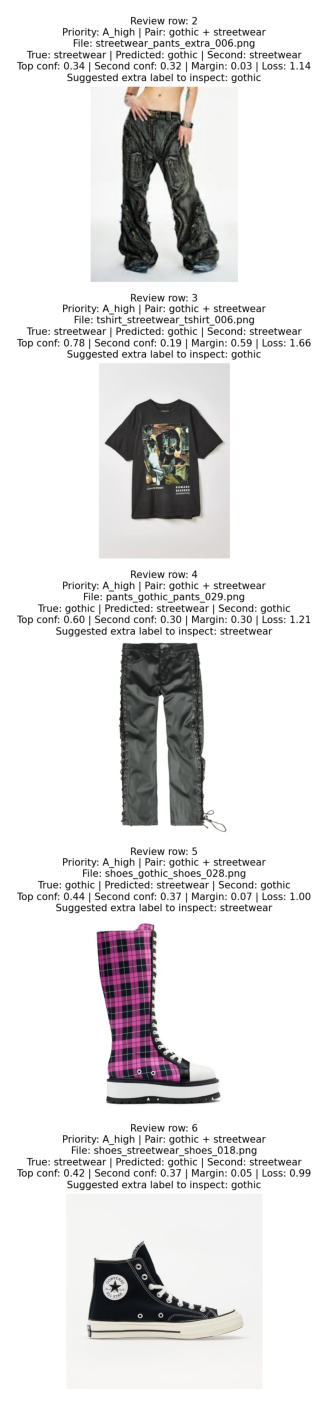

In [16]:
first_sheet_path = saved_sheet_paths[0]

img = Image.open(first_sheet_path)

plt.figure(figsize=(10, 18))
plt.imshow(img)
plt.axis("off")
plt.show()

## 21. Load Completed Manual Review

Now that the manual review sheet has been completed, I load it back into the notebook.

The completed file contains the manual multi-label decisions for the selected candidate images. Each image can now have one or more style labels.

In [18]:
completed_review_path = manual_review_dir / "style_multilabel_manual_review_completed.xlsx"

manual_completed_df = pd.read_excel(completed_review_path)

print("Completed manual review file:", completed_review_path)
print("Rows loaded:", len(manual_completed_df))
print("Columns:", manual_completed_df.columns.tolist())

manual_completed_df.head()

Completed manual review file: ..\results\style_multilabel_error_analysis\manual_review\style_multilabel_manual_review_completed.xlsx
Rows loaded: 115
Columns: ['review_priority', 'review_pair', 'source', 'split', 'filename', 'image_path', 'true_style', 'predicted_style', 'second_style', 'suggested_second_label', 'top_confidence', 'second_confidence', 'confidence_margin', 'loss', 'wrong_prediction', 'high_loss', 'low_margin', 'low_confidence', 'manual_formal', 'manual_gothic', 'manual_sporty', 'manual_streetwear', 'review_decision', 'manual_notes']


,review_priority,review_pair,source,split,filename,image_path,true_style,predicted_style,second_style,suggested_second_label,...,wrong_prediction,high_loss,low_margin,low_confidence,manual_formal,manual_gothic,manual_sporty,manual_streetwear,review_decision,manual_notes
0,A_high,gothic + streetwear,style_extra,style_extra,streetwear_pants_extra_006.png,..\dataset\style_extra\streetwear\pants\street...,streetwear,gothic,streetwear,gothic,...,True,True,True,True,0,1,0,1,add_second_label,Dark shiny oversized pants can work as streetw...
1,A_high,gothic + streetwear,split_style_train,train,tshirt_streetwear_tshirt_006.png,..\dataset\split_style\train\streetwear\tshirt...,streetwear,gothic,streetwear,gothic,...,True,True,False,False,0,1,0,1,add_second_label,"Black oversized graphic tee is streetwear, but..."
2,A_high,gothic + streetwear,split_style_train,train,pants_gothic_pants_029.png,..\dataset\split_style\train\gothic\pants_goth...,gothic,streetwear,gothic,streetwear,...,True,True,False,True,0,1,0,1,add_second_label,Clearly gothic because of the lacing/leather l...
3,A_high,gothic + streetwear,split_style_train,train,shoes_gothic_shoes_028.png,..\dataset\split_style\train\gothic\shoes_goth...,gothic,streetwear,gothic,streetwear,...,True,False,True,True,0,1,0,0,keep_single_label,These are very clearly gothic/punk boots. Stre...
4,A_high,gothic + streetwear,split_style_train,train,shoes_streetwear_shoes_018.png,..\dataset\split_style\train\streetwear\shoes_...,streetwear,gothic,streetwear,gothic,...,True,False,True,True,0,0,0,1,keep_single_label,Black Converse-style shoes are common streetwe...


## 22. Validate Manual Review Decisions

Before using the manual labels for training, I validate the completed review file.

This checks whether the required columns exist, whether each manual label is either 0 or 1, and whether every reviewed image still has at least one style label.

In [19]:
required_manual_columns = [
    "image_path",
    "filename",
    "true_style",
    "manual_formal",
    "manual_gothic",
    "manual_sporty",
    "manual_streetwear",
    "review_decision",
    "manual_notes"
]

missing_columns = [
    col for col in required_manual_columns
    if col not in manual_completed_df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

manual_label_columns = [
    "manual_formal",
    "manual_gothic",
    "manual_sporty",
    "manual_streetwear"
]

# Clean label columns
for col in manual_label_columns:
    manual_completed_df[col] = manual_completed_df[col].fillna(0).astype(int)

# Normalize paths for safer merging later
manual_completed_df["image_path_key"] = (
    manual_completed_df["image_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

manual_completed_df["label_count"] = manual_completed_df[manual_label_columns].sum(axis=1)

print("Review decision counts:")
display(manual_completed_df["review_decision"].value_counts(dropna=False))

print("Label count distribution:")
display(manual_completed_df["label_count"].value_counts().sort_index())

# Check for invalid label values
for col in manual_label_columns:
    invalid_values = manual_completed_df[~manual_completed_df[col].isin([0, 1])]
    if len(invalid_values) > 0:
        print(f"Invalid values found in {col}:")
        display(invalid_values[["filename", col]])

# Check rows with no labels
no_label_rows = manual_completed_df[manual_completed_df["label_count"] == 0]

print("Rows with no labels:", len(no_label_rows))

if len(no_label_rows) > 0:
    display(no_label_rows[["filename", "true_style", "review_decision"] + manual_label_columns])

# Check duplicate image paths
duplicate_rows = manual_completed_df[
    manual_completed_df["image_path_key"].duplicated(keep=False)
]

print("Duplicate reviewed image paths:", len(duplicate_rows))

if len(duplicate_rows) > 0:
    display(duplicate_rows[["filename", "image_path"]])

Review decision counts:


review_decision
keep_single_label    59
add_second_label     56
Name: count, dtype: int64

Label count distribution:


label_count
1    59
2    56
Name: count, dtype: int64

Rows with no labels: 0
Duplicate reviewed image paths: 0


## 23. Manual Relabeling Summary

This section summarizes what changed during manual review.

The goal is to see how many images stayed single-label and how many became multi-label. This helps explain how much of the dataset was actually adjusted.

In [20]:
def get_manual_label_names(row):
    labels = []

    if row["manual_formal"] == 1:
        labels.append("formal")
    if row["manual_gothic"] == 1:
        labels.append("gothic")
    if row["manual_sporty"] == 1:
        labels.append("sporty")
    if row["manual_streetwear"] == 1:
        labels.append("streetwear")

    return " + ".join(labels)


manual_completed_df["manual_label_names"] = manual_completed_df.apply(
    get_manual_label_names,
    axis=1
)

manual_completed_df["became_multilabel"] = manual_completed_df["label_count"] > 1

manual_summary = {
    "reviewed_images": len(manual_completed_df),
    "single_label_after_review": int((manual_completed_df["label_count"] == 1).sum()),
    "multi_label_after_review": int((manual_completed_df["label_count"] > 1).sum()),
    "average_labels_per_reviewed_image": manual_completed_df["label_count"].mean()
}

manual_summary_df = pd.DataFrame([manual_summary])

display(manual_summary_df)

print("Manual label combination counts:")
manual_label_combination_counts = (
    manual_completed_df["manual_label_names"]
    .value_counts()
    .reset_index()
)

manual_label_combination_counts.columns = ["manual_label_combination", "count"]

display(manual_label_combination_counts)

print("Manual label totals:")
manual_label_totals = manual_completed_df[manual_label_columns].sum().reset_index()
manual_label_totals.columns = ["manual_label", "count"]

display(manual_label_totals)

,reviewed_images,single_label_after_review,multi_label_after_review,average_labels_per_reviewed_image
0,115,59,56,1.486957


Manual label combination counts:


,manual_label_combination,count
0,streetwear,40
1,sporty + streetwear,35
2,sporty,10
3,formal + streetwear,9
4,gothic + streetwear,7
5,formal,6
6,formal + gothic,5
7,gothic,3


Manual label totals:


,manual_label,count
0,manual_formal,20
1,manual_gothic,15
2,manual_sporty,45
3,manual_streetwear,91


## 24. Create Final Multi-Label Training Labels

The current training dataset is folder-based, so each image originally has one style label.

For multi-label training, I create a new CSV file. All normal training images keep their original single label. The manually reviewed candidate images use the updated manual labels.

This gives a training label file that can be used with `BCEWithLogitsLoss`.

In [21]:
train_sources = ["split_style_train", "style_extra"]

base_train_df = analysis_df[
    analysis_df["source"].isin(train_sources)
].copy()

base_train_df["image_path_key"] = (
    base_train_df["image_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

# Create default one-hot labels from the original folder label
for style in class_names:
    base_train_df[f"default_{style}"] = (
        base_train_df["true_style"] == style
    ).astype(int)

# Prepare manual override labels
manual_override_df = manual_completed_df[
    [
        "image_path_key",
        "review_decision",
        "manual_notes",
        "manual_label_names"
    ] + manual_label_columns
].copy()

manual_override_df = manual_override_df.rename(columns={
    "manual_formal": "reviewed_formal",
    "manual_gothic": "reviewed_gothic",
    "manual_sporty": "reviewed_sporty",
    "manual_streetwear": "reviewed_streetwear"
})

# Merge manual labels onto the full training dataset
final_train_df = base_train_df.merge(
    manual_override_df,
    on="image_path_key",
    how="left"
)

final_train_df["was_manually_reviewed"] = final_train_df["review_decision"].notna()

# Use manual labels where available, otherwise keep original one-hot folder label
for style in class_names:
    default_col = f"default_{style}"
    reviewed_col = f"reviewed_{style}"
    final_col = f"label_{style}"

    final_train_df[final_col] = np.where(
        final_train_df["was_manually_reviewed"],
        final_train_df[reviewed_col],
        final_train_df[default_col]
    ).astype(int)

final_label_columns = [f"label_{style}" for style in class_names]

final_train_df["label_count"] = final_train_df[final_label_columns].sum(axis=1)

# Fill empty text fields
final_train_df["review_decision"] = final_train_df["review_decision"].fillna("not_reviewed")
final_train_df["manual_notes"] = final_train_df["manual_notes"].fillna("")
final_train_df["manual_label_names"] = final_train_df["manual_label_names"].fillna("")

final_columns = [
    "source",
    "split",
    "filename",
    "image_path",
    "true_style",
    "was_manually_reviewed",
    "review_decision",
    "manual_label_names",
    "manual_notes"
] + final_label_columns + [
    "label_count"
]

final_multilabel_train_df = final_train_df[final_columns].copy()

final_multilabel_path = results_dir / "style_multilabel_train_labels.csv"

final_multilabel_train_df.to_csv(final_multilabel_path, index=False)

print("Saved final multi-label training CSV to:", final_multilabel_path)
print("Rows:", len(final_multilabel_train_df))

final_multilabel_train_df.head()

Saved final multi-label training CSV to: ..\results\style_multilabel_error_analysis\style_multilabel_train_labels.csv
Rows: 660


,source,split,filename,image_path,true_style,was_manually_reviewed,review_decision,manual_label_names,manual_notes,label_formal,label_gothic,label_sporty,label_streetwear,label_count
0,split_style_train,train,jacket_formal_jacket_001.png,..\dataset\split_style\train\formal\jacket_for...,formal,False,not_reviewed,,,1,0,0,0,1
1,split_style_train,train,jacket_formal_jacket_003.png,..\dataset\split_style\train\formal\jacket_for...,formal,False,not_reviewed,,,1,0,0,0,1
2,split_style_train,train,jacket_formal_jacket_004.png,..\dataset\split_style\train\formal\jacket_for...,formal,False,not_reviewed,,,1,0,0,0,1
3,split_style_train,train,jacket_formal_jacket_005.png,..\dataset\split_style\train\formal\jacket_for...,formal,False,not_reviewed,,,1,0,0,0,1
4,split_style_train,train,jacket_formal_jacket_006.png,..\dataset\split_style\train\formal\jacket_for...,formal,False,not_reviewed,,,1,0,0,0,1


## 25. Validate Final Multi-Label Training File

The final training CSV is validated to make sure it is usable for the next experiment.

The checks confirm that every image has at least one label and that manually reviewed images were applied correctly.

In [22]:
print("Final dataset rows:", len(final_multilabel_train_df))
print("Manually reviewed rows:", final_multilabel_train_df["was_manually_reviewed"].sum())

print("Label count distribution:")
display(final_multilabel_train_df["label_count"].value_counts().sort_index())

print("Final label totals:")
final_label_totals = final_multilabel_train_df[final_label_columns].sum().reset_index()
final_label_totals.columns = ["label", "count"]
display(final_label_totals)

print("Label count by source:")
display(
    pd.crosstab(
        final_multilabel_train_df["source"],
        final_multilabel_train_df["label_count"]
    )
)

zero_label_rows = final_multilabel_train_df[
    final_multilabel_train_df["label_count"] == 0
]

print("Rows with zero labels:", len(zero_label_rows))

if len(zero_label_rows) > 0:
    display(zero_label_rows[["filename", "image_path", "review_decision"] + final_label_columns])

reviewed_check = final_multilabel_train_df[
    final_multilabel_train_df["was_manually_reviewed"]
]

display(
    reviewed_check[
        [
            "filename",
            "true_style",
            "review_decision",
            "manual_label_names"
        ] + final_label_columns
    ].head(20)
)

Final dataset rows: 660
Manually reviewed rows: 115
Label count distribution:


label_count
1    604
2     56
Name: count, dtype: int64

Final label totals:


,label,count
0,label_formal,169
1,label_gothic,147
2,label_sporty,182
3,label_streetwear,218


Label count by source:


label_count,1,2
source,,
split_style_train,515,45
style_extra,89,11


Rows with zero labels: 0


,filename,true_style,review_decision,manual_label_names,label_formal,label_gothic,label_sporty,label_streetwear
9,jacket_formal_jacket_015.png,formal,keep_single_label,formal,1,0,0,0
11,jacket_formal_jacket_017.png,formal,add_second_label,formal + gothic,1,1,0,0
12,jacket_formal_jacket_019.png,formal,add_second_label,formal + gothic,1,1,0,0
23,jacket_formal_jacket_038.png,formal,keep_single_label,formal,1,0,0,0
33,pants_formal_pants_002.png,formal,keep_single_label,formal,1,0,0,0
126,tshirt_formal_tshirt_029.png,formal,add_second_label,formal + streetwear,1,0,0,1
128,tshirt_formal_tshirt_031.png,formal,add_second_label,formal + streetwear,1,0,0,1
129,tshirt_formal_tshirt_034.png,formal,add_second_label,formal + streetwear,1,0,0,1
137,tshirt_formal_tshirt_047.png,formal,keep_single_label,formal,1,0,0,0
152,jacket_gothic_jacket_021.png,gothic,add_second_label,formal + gothic,1,1,0,0


## 26. Final Experiment Summary

This section saves a short summary of the relabeling experiment.

The output of this notebook is not a trained model yet. The main output is a clean multi-label training CSV that can be used in the next notebook.

In [23]:
experiment_summary = {
    "experiment": "Style Error Analysis for Multi-Label Relabeling",
    "selected_style_model": "style_mobilenet_v3_large_architecture_comparison.pth",
    "base_train_sources": ", ".join(train_sources),
    "final_training_rows": len(final_multilabel_train_df),
    "manual_reviewed_rows": int(final_multilabel_train_df["was_manually_reviewed"].sum()),
    "single_label_training_rows": int((final_multilabel_train_df["label_count"] == 1).sum()),
    "multi_label_training_rows": int((final_multilabel_train_df["label_count"] > 1).sum()),
    "average_labels_per_training_image": float(final_multilabel_train_df["label_count"].mean()),
    "output_file": str(final_multilabel_path),
    "main_result": (
        "A focused manual review was used to create multi-label training labels "
        "for selected ambiguous fashion items while keeping clear examples single-label."
    ),
    "next_step": (
        "Train a multi-label MobileNetV3 style classifier using BCEWithLogitsLoss "
        "and sigmoid outputs."
    )
}

experiment_summary_df = pd.DataFrame([experiment_summary])

summary_path = results_dir / "style_multilabel_error_analysis_summary.csv"

experiment_summary_df.to_csv(summary_path, index=False)

print("Saved experiment summary to:", summary_path)

display(experiment_summary_df)

Saved experiment summary to: ..\results\style_multilabel_error_analysis\style_multilabel_error_analysis_summary.csv


,experiment,selected_style_model,base_train_sources,final_training_rows,manual_reviewed_rows,single_label_training_rows,multi_label_training_rows,average_labels_per_training_image,output_file,main_result,next_step
0,Style Error Analysis for Multi-Label Relabeling,style_mobilenet_v3_large_architecture_comparis...,"split_style_train, style_extra",660,115,604,56,1.084848,..\results\style_multilabel_error_analysis\sty...,A focused manual review was used to create mul...,Train a multi-label MobileNetV3 style classifi...
